In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data of gurugram real Estate.csv')
df.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Society,Company Name,Flat Type
0,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4,Outside Socity,Outside,Plot
4,24000000,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3,Anant Raj Estate Plots,Anant,Floor


In [3]:
# Data Cleaning
# columns standardization
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')
print(df.columns.tolist())
df = df.drop_duplicates()

['price', 'status', 'area', 'rate_per_sqft', 'property_type', 'locality', 'builder_name', 'rera_approval', 'bhk_count', 'society', 'company_name', 'flat_type']


In [4]:
df.describe()

,area,bhk_count
count,14223.000000,14223.000000
mean,2621.755959,3.266189
std,11125.298077,5.496692
min,60.000000,0.000000
25%,1424.000000,2.000000
50%,2015.000000,3.000000
75%,2840.500000,4.000000
max,958320.000000,132.000000


In [5]:
df.shape

(14223, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14223 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price          14223 non-null  object
 1   status         14223 non-null  object
 2   area           14223 non-null  int64 
 3   rate_per_sqft  14223 non-null  object
 4   property_type  14223 non-null  object
 5   locality       14223 non-null  object
 6   builder_name   14223 non-null  object
 7   rera_approval  14223 non-null  object
 8   bhk_count      14223 non-null  int64 
 9   society        14223 non-null  object
 10  company_name   14223 non-null  object
 11  flat_type      14223 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.4+ MB


In [7]:
# Numerical Columns Cleaning
df['price'] = df['price'].astype(str).str.replace(',','').astype(float)
df['area'] = df['area'].astype(str).str.replace(',','').astype(int)
df['rate_per_sqft'] = df['rate_per_sqft'].astype(str).str.replace(',','').astype(int)
print(df['rate_per_sqft'])


0         9450
1         9450
2         9450
3         8888
4        13333
         ...  
19510    17500
19511    17500
19512    16002
19513    16001
19514    16005
Name: rate_per_sqft, Length: 14223, dtype: int64


In [8]:
#Categorical Columns Cleaning
df['status'] = df['status'].str.strip().str.lower()
df['rera_approval'] = df['rera_approval'].str.strip().str.lower().map({'approved by rera': True, 'not approved by rera' : False})
df['flat_type'] = df['flat_type'].str.strip().str.lower()
df = df.drop_duplicates()

In [9]:
df

,price,status,area,rate_per_sqft,property_type,locality,builder_name,rera_approval,bhk_count,society,company_name,flat_type
0,10700000.0,under construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,True,2,M3M Antalya Hills Phase I,M3M,apartment
1,14400000.0,under construction,1528,9450,3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,True,3,M3M Antalya Hills Phase I,M3M,apartment
2,10700000.0,under construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,True,2,M3M Antalya Hills Phase I,M3M,apartment
3,40000000.0,ready to move,4500,8888,4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,False,4,Outside Socity,Outside,plot
4,24000000.0,under construction,1800,13333,3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,True,3,Anant Raj Estate Plots,Anant,floor
...,...,...,...,...,...,...,...,...,...,...,...,...
19510,24100000.0,ready to move,1381,17500,2 BHK Apartment in Sobha City,Sector 108,Shree Realstic One,False,2,Sobha City,Sobha,apartment
19511,36200000.0,ready to move,2072,17500,3 BHK Apartment in Sobha City,Sector 108,Shree Realstic One,False,3,Sobha City,Sobha,apartment
19512,39100000.0,under construction,2445,16002,3 BHK Apartment in Pyramid Alban,Sector 71,Shree Realstic One,True,3,Pyramid Alban,Pyramid,apartment
19513,37700000.0,under construction,2360,16001,3 BHK Apartment in Pyramid Alban,Sector 71,Shree Realstic One,True,3,Pyramid Alban,Pyramid,apartment


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14223 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          14223 non-null  float64
 1   status         14223 non-null  object 
 2   area           14223 non-null  int64  
 3   rate_per_sqft  14223 non-null  int64  
 4   property_type  14223 non-null  object 
 5   locality       14223 non-null  object 
 6   builder_name   14223 non-null  object 
 7   rera_approval  14223 non-null  bool   
 8   bhk_count      14223 non-null  int64  
 9   society        14223 non-null  object 
 10  company_name   14223 non-null  object 
 11  flat_type      14223 non-null  object 
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 1.3+ MB


In [11]:
# Question 1: Which is the costliest flat in the database?
costliest_flat = df.loc[df['price'].idxmax()]
costliest_flat

price                                1226300000.0
status                              ready to move
area                                        16500
rate_per_sqft                               74323
property_type    6 BHK Apartment in DLF Camellias
locality                                Sector 42
builder_name                    Provident Capital
rera_approval                               False
bhk_count                                       6
society                             DLF Camellias
company_name                                  DLF
flat_type                               apartment
Name: 2839, dtype: object

In [12]:
# Question 2: Which locality has the highest average price?
highest_avg_price_locality = df.groupby('locality')['price'].mean().idxmax()
highest_avg_price_locality

'Baliawas'

In [13]:
# Question 3: Which locality has the highest rate per square foot?
highest_rate_locality = df.groupby('locality')['rate_per_sqft'].mean().idxmax()
highest_rate_locality

'Sector 42'

In [14]:
# Question 4 : Do ready-to-move properties cost more than under-construction properties?
ready_to_move_avg_price = df[df['status'] == 'ready to move']['price'].mean()
under_construction_avg_price = df[df['status'] == 'under construction']['price'].mean()

if ready_to_move_avg_price > under_construction_avg_price:
    print('Ready-to-move-flat cost more on average than under-construction flat')
else:
    print('Under-Construction-flat cost more on average than ready-to-move-flat')

Ready-to-move-flat cost more on average than under-construction flat


In [15]:
# Question 5 : Do RERA-approved properties command a price premium?
approved_by_rera = df[df['rera_approval'] == True]['price'].mean()
not_approved_by_rera = df[df['rera_approval'] == False]['price'].mean()

if approved_by_rera > not_approved_by_rera:
    print('RERA approved flats command higher price')
else:
    print('RERA approval has no relationship with the price')

RERA approval has no relationship with the price


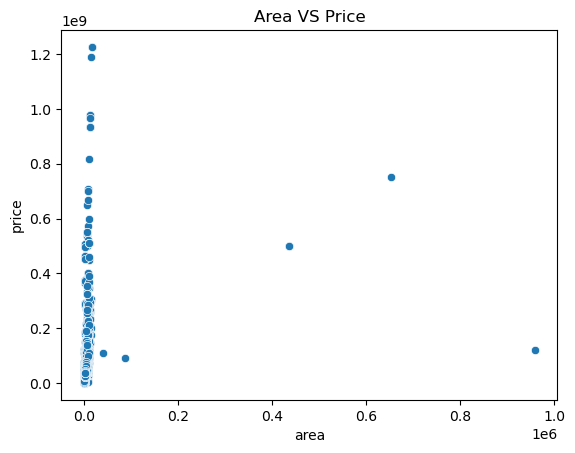

In [16]:
# Question 6: How does area (sqft) impact property price?
sns.scatterplot(data=df, x='area', y='price')
plt.title('Area VS Price')
plt.show()

No,Area(sqft) don't impact property price,because flat with same square feet have different prices across different locations.

In [17]:
# Question 7 : Which BHK configuration is the most expensive on average based on per square feet rate?
most_expensive_bhk = df.groupby('bhk_count')['rate_per_sqft'].mean().idxmax()
print(f"The most expensive Bhk count is {most_expensive_bhk}.")

The most expensive Bhk count is 114.


In [18]:
# Question 8 : Which property type (Apartment, Floor, Plot) is the costliest?
costliest_property_type = df.groupby('flat_type')['rate_per_sqft'].mean().idxmax()
print(f"The costliest property type is {costliest_property_type}.")

The costliest property type is villa.


In [19]:
# Question 9: Do certain builders price higher?
print(df.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False).head(5))

company_name
Camelliaass    44724.333333
Cameliaas      40000.000000
Tulip          28571.121495
Prom           27358.600000
Magnoliaass    26666.000000
Name: rate_per_sqft, dtype: float64


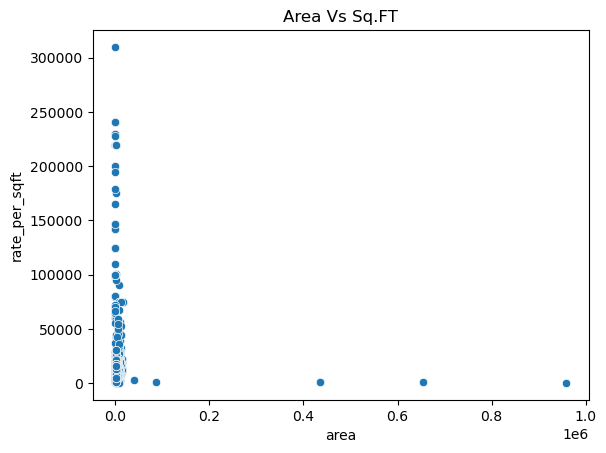

In [22]:
# Question 10 : Are larger homes more expensive per square feet?
sns.scatterplot(data=df, x='area', y='rate_per_sqft')
plt.title('Area Vs Sq.FT')
plt.show()

No,larger homes are not expensive.After analysing this dataset we came to a conclusion that price of home depends on location factor.